## Data Pipelines - Prefect - Example and Workshop
### Big Data Tools 
#### M.Sc. in Applied Analytics (coterminal course)
Fac. de Ingeniería -  Universidad de la Sabana<br>
Prof.: Hugo Franco, Ph.D.

In [ ]:
import os
os.environ['OMP_NUM_THREADS'] = '1'  # prevenir problemas con threads

from prefect import flow, task, get_run_logger
import pandas as pd
from kaggle import KaggleApi
import logging

# Constantes
LOCAL_KAGGLE_DIR = './auth'
DOWNLOAD_DIRECTORY = './data'
TARGET_DATASET = 'sushilyeotiwad/wheat-seed-dataset'

# Crear directorio de descarga si no existe
if not os.path.exists(DOWNLOAD_DIRECTORY):
    print(f"Creating directory: {DOWNLOAD_DIRECTORY}")
    os.makedirs(DOWNLOAD_DIRECTORY)


@task(retries=3, retry_delay_seconds=10, name="Authenticate")
def api_authenticate():
    logger = get_run_logger()
    try:
        logger.info(" Autenticando en Kaggle...")
        api = KaggleApi()
        api.authenticate()
        logger.info(" Autenticación exitosa")
        return api
    except Exception as e:
        logger.error(f"Error en la autenticación: {e}")
        return None   # Devuelve None si falla


@task(name="Download & Load Dataset")
def download_and_load(api, dataset_id: str, download_path: str):
    logger = get_run_logger()
    if api is None:
        logger.error(" No se pudo autenticar. No se descargará el dataset.")
        return None

    try:
        logger.info(f" Descargando dataset '{dataset_id}' en '{download_path}'...")
        api.dataset_download_files(dataset_id, path=download_path, unzip=True)

        
        os.chdir(download_path)

        
        df = pd.read_csv("seeds_dataset.csv")
        logger.info(f" Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas")

        
        df_clustering = df.drop('Class_(1, 2, 3)', axis=1)
        return df_clustering

    except Exception as e:
        logger.error(f" Error descargando o cargando el dataset: {e}")
        return None


@flow(name="Pipeline Seeds Dataset")
def extract_data():
    kaggle_api = api_authenticate()
    df = download_and_load(kaggle_api, TARGET_DATASET, DOWNLOAD_DIRECTORY)
    if df is not None:
        print(df.head())   # Mostrar primeras filas
    else:
        print(" Pipeline completado pero sin datos válidos.")

extract_data()
os.chdir(DOWNLOAD_DIRECTORY)
df_seeds = pd.read_csv('seeds_dataset.csv')
# Basic data cleansing: Exclude the 'Class' column as it's the target variable and we're looking for independent variables for clustering.
df_clustering = df_seeds.drop('Class_(1, 2, 3)', axis=1)


10:38:39.598 | INFO    | Flow run 'statuesque-kittiwake' - Beginning flow run 'statuesque-kittiwake' for flow 'Pipeline Seeds Dataset'

10:38:39.691 | INFO    | Task run 'Authenticate-806' -  Autenticando en Kaggle...

10:38:39.700 | INFO    | Task run 'Authenticate-806' -  Autenticación exitosa

10:38:39.714 | INFO    | Task run 'Authenticate-806' - Finished in state Completed()

10:38:39.811 | INFO    | Task run 'Download & Load Dataset-0d4' -  Descargando dataset 'sushilyeotiwad/wheat-seed-dataset' en './data'...

Dataset URL: https://www.kaggle.com/datasets/sushilyeotiwad/wheat-seed-dataset


10:38:40.579 | INFO    | Task run 'Download & Load Dataset-0d4' -  Dataset cargado con 210 filas y 8 columnas

10:38:40.603 | INFO    | Task run 'Download & Load Dataset-0d4' - Finished in state Completed()

    Area  Perimeter  Compactness  Length_of_ kernel  Width_of_kernel  \
0  15.26      14.84       0.8710              5.763            3.312   
1  14.88      14.57       0.8811              5.554            3.333   
2  14.29      14.09       0.9050              5.291            3.337   
3  13.84      13.94       0.8955              5.324            3.379   
4  16.14      14.99       0.9034              5.658            3.562   

   Asymmetry_coefficient  Length_of_kernel_groove  
0                  2.221                    5.220  
1                  1.018                    4.956  
2                  2.699                    4.825  
3                  2.259                    4.805  
4                  1.355                    5.175  


10:38:40.711 | INFO    | Flow run 'statuesque-kittiwake' - Finished in state Completed()

### Basic (Unsupervised) Machine Learning analytics method
 Determine, by clustering, a sound number of species within the wheat seed dataset

 Firstly, identify the less correlated pair of features and use them as the representation for the instances in the dataset

The lowest absolute correlation is 0.0111, between ('Length_of_kernel_groove', 'Asymmetry_coefficient')


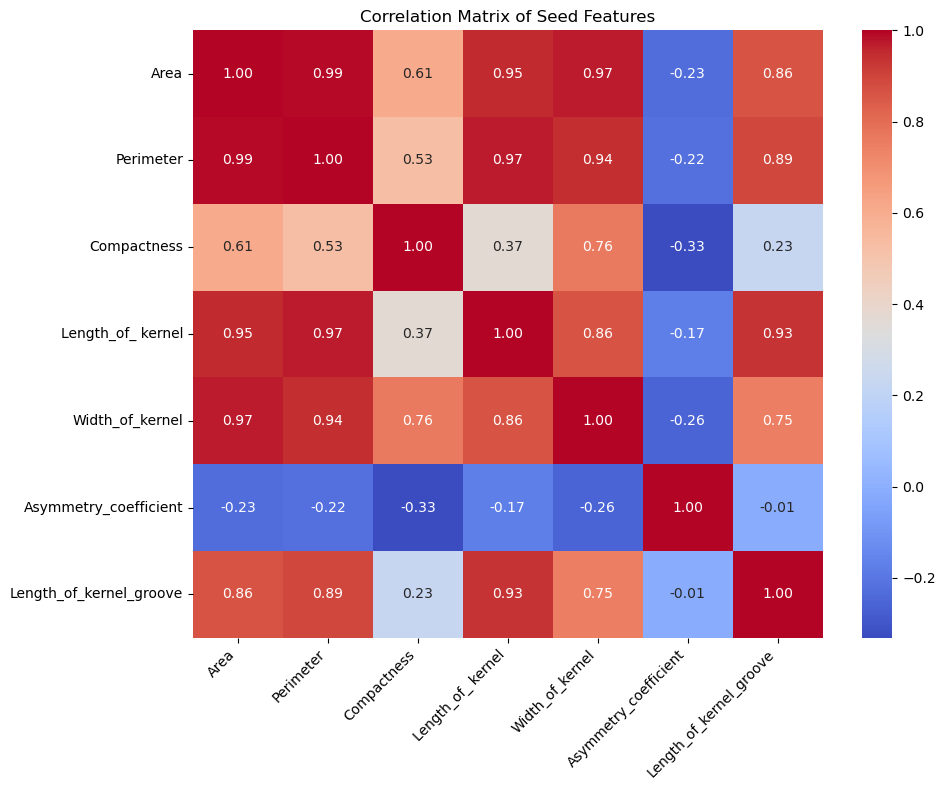

In [2]:
# Calculate the correlation matrix.
correlation_matrix = df_clustering.corr()

# Find the pair of variables with the lowest absolute correlation.
# We take the upper triangle of the correlation matrix and flatten it, and ignore the diagonal (which are all 1).
# We then find the minimum value and the corresponding row and column.
lower_triangle = correlation_matrix.mask(np.triu(np.ones(correlation_matrix.shape)).astype(bool))
lowest_corr = lower_triangle.stack().abs().min()
lowest_corr_pair = lower_triangle.stack().abs().idxmin()

# Print the lowest correlation and the corresponding pair of variables.
print(f"The lowest absolute correlation is {lowest_corr:.4f}, between {lowest_corr_pair}")

# Plot a heatmap of the correlation matrix for visualization.
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Seed Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

Now, use the `KMeans` clustering method to perform an unsupervised approach to the identification of the number of species in the dataset, according to the observations 

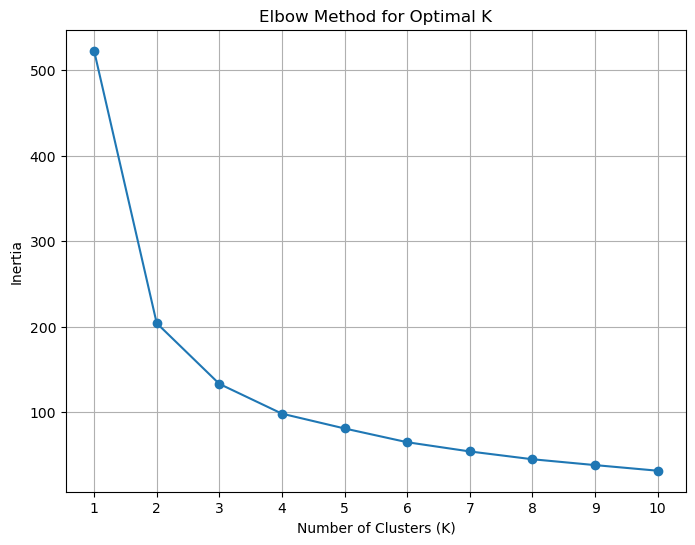

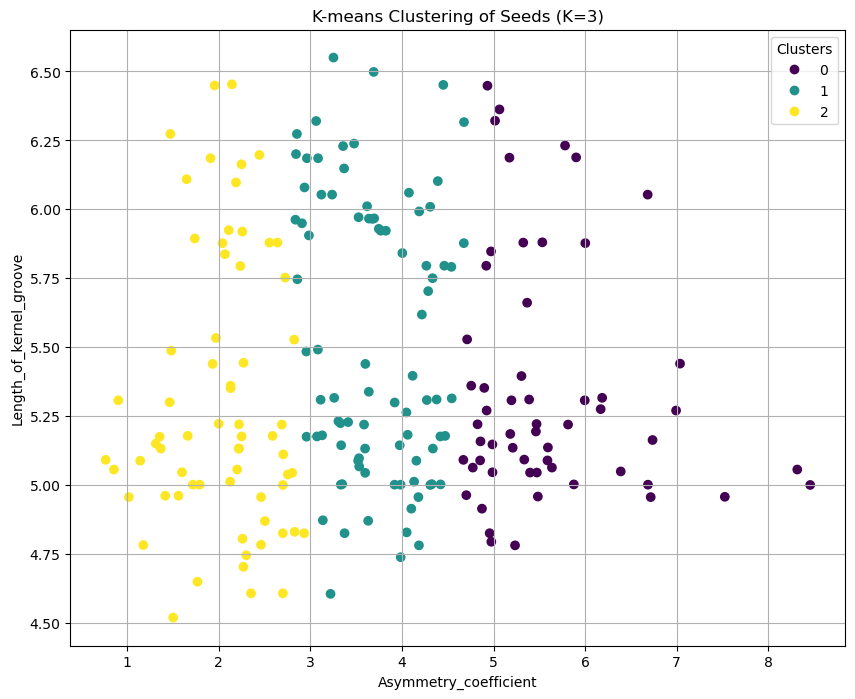

In [3]:
# Select the two variables for clustering.
X = df_clustering[['Asymmetry_coefficient', 'Length_of_kernel_groove']]

# Determine the optimal number of clusters using the Elbow Method.
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method results.
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.savefig('elbow_method.png')
plt.show()

# Based on the Elbow plot, choose the optimal number of clusters.
# For this dataset, the 'Class' column suggests ?? classes, and the elbow method plot shows a good elbow at k=??.
optimal_k = 3

# Perform K-means clustering with the optimal number of clusters.
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clustering['cluster'] = kmeans_model.fit_predict(X)

# Visualize the clustering results.
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_clustering['Asymmetry_coefficient'], df_clustering['Length_of_kernel_groove'], c=df_clustering['cluster'], cmap='viridis')
plt.title('K-means Clustering of Seeds (K=3)')
plt.xlabel('Asymmetry_coefficient')
plt.ylabel('Length_of_kernel_groove')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True)
plt.savefig('kmeans_clustering_plot.png')
plt.show()



__Challenges (Workshop 3, part 2):__
1. Organize the code of the example and complete the data pipeline: 
    - Use `try-except-finally` blocks as required 
    - Every individual process must be wrapped as a `task` using the corresponding decorator and its parameters when necessary. 
    - Create a `transform_data` task focused on data cleansing
    - Create a `load_data` task to create a table in a Dockerized PostgreSQL database and populate with with the clustering-oriented Dataframe
    - Invoke the tasks in the proper order in the `flow`
    - Use the `timing_decorator` to report the duration of each task 
1. Using the function get_directory_size, create a decorator to get and report the size of the downloaded dataset (size in bytes of the download folder)
1. Report the size in the previous question in a human readable unit
1. Use the attribute kmeans.cluster_centers_ and scatter plot to add the centroids of the best KMeans model (best K parameter) to the scatter plot
    - `centroids = kmeans.cluster_centers_`


In [ ]:
def get_directory_size(path='.'):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            # Create the full file path by joining the directory path and file name
            fp = os.path.join(dirpath, f)
            # Skip symbolic links to avoid counting them
            if not os.path.islink(fp):
                total_size += os.path.getsize(fp)
    return total_size

def human_readable_size(size_in_bytes):
    for unit in ['B', 'KB', 'MB', 'GB', 'TB']:
        if size_in_bytes < 1024:
            return f"{size_in_bytes:.2f} {unit}"
        size_in_bytes /= 1024

def report_dataset_size(path='.'):
    def decorator(func):
        def wrapper(*args, **kwargs):
            before_size = get_directory_size(path)
            print(f"Dataset size: {before_size} bytes "
                  f"({human_readable_size(before_size)})")

            result = func(*args, **kwargs)

            return result
        return wrapper
    return decorator

@report_dataset_size(path="data")
def download_dataset():
    print("")

download_dataset()

Dataset size: 442059 bytes (431.70 KB)



In [20]:
import psycopg2
from psycopg2 import sql
from prefect import task, flow, get_run_logger
import pandas as pd

@task
def load_data(df: pd.DataFrame):
    logger = get_run_logger()
    try:
        conn = psycopg2.connect(
            host="localhost",
            port="5432",
            dbname="bigdatatools1",
            user="psqluser",
            password="psqlpass"
        )
        cur = conn.cursor()
        logger.info("Conexión exitosa a PostgreSQL")

        # Elimina y crea tabla
        cur.execute("DROP TABLE IF EXISTS clustering_data;")
        create_table_query = sql.SQL("""
        CREATE TABLE clustering_data (
            id SERIAL PRIMARY KEY,
            {}
        );
        """).format(
            sql.SQL(", ").join(
                sql.SQL("{} FLOAT").format(sql.Identifier(col)) for col in df.columns
            )
        )
        cur.execute(create_table_query)
        conn.commit()
        logger.info("Tabla clustering_data creada")

        # Insertar datos
        insert_query = sql.SQL(
            "INSERT INTO clustering_data ({}) VALUES ({})"
        ).format(
            sql.SQL(", ").join(map(sql.Identifier, df.columns)),
            sql.SQL(", ").join(sql.Placeholder() * len(df.columns))
        )

        for _, row in df.iterrows():
            cur.execute(insert_query, tuple(row))

        conn.commit()
        logger.info("Datos insertados en clustering_data")

        cur.close()
        conn.close()

    except Exception as e:
        logger.error(f"Error en load_data: {e}")

@task
def check_data():
    conn = psycopg2.connect(
        host="localhost",
        port="5432",
        dbname="bigdatatools1",
        user="psqluser",
        password="psqlpass"
    )
    df_check = pd.read_sql("SELECT * FROM clustering_data LIMIT 10;", conn)
    print("Datos cargados en la tabla clustering_data:")
    print(df_check)
    conn.close()

@flow
def etl_flow():
    df = pd.read_csv("seeds_dataset.csv")

    load_data(df)

    check_data()

etl_flow()

12:14:17.303 | INFO    | Flow run 'omniscient-ocelot' - Beginning flow run 'omniscient-ocelot' for flow 'etl-flow'

12:14:17.418 | INFO    | Task run 'load_data-7da' - Conexión exitosa a PostgreSQL

12:14:17.474 | INFO    | Task run 'load_data-7da' - Tabla clustering_data creada

12:14:17.540 | INFO    | Task run 'load_data-7da' - Datos insertados en clustering_data

12:14:17.543 | INFO    | Task run 'load_data-7da' - Finished in state Completed()

Datos cargados en la tabla clustering_data:
   id   Area  Perimeter  Compactness  Length_of_ kernel  Width_of_kernel  \
0   1  15.26      14.84       0.8710              5.763            3.312   
1   2  14.88      14.57       0.8811              5.554            3.333   
2   3  14.29      14.09       0.9050              5.291            3.337   
3   4  13.84      13.94       0.8955              5.324            3.379   
4   5  16.14      14.99       0.9034              5.658            3.562   
5   6  14.38      14.21       0.8951              5.386            3.312   
6   7  14.69      14.49       0.8799              5.563            3.259   
7   8  14.11      14.10       0.8911              5.420            3.302   
8   9  16.63      15.46       0.8747              6.053            3.465   
9  10  16.44      15.25       0.8880              5.884            3.505   

   Asymmetry_coefficient  Length_of_kernel_groove  Class_(1, 2, 3)  
0                  2.221                    5.220 

/var/folders/9x/t31_zr3x4jb0mwg24kwr06ch0000gn/T/ipykernel_23466/2081824654.py:65: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_check = pd.read_sql("SELECT * FROM clustering_data LIMIT 10;", conn)


12:14:17.594 | INFO    | Task run 'check_data-13a' - Finished in state Completed()

12:14:17.605 | INFO    | Flow run 'omniscient-ocelot' - Finished in state Completed()